# Citation Graph Demo
This notebook demonstrates how to build and visualize a citation graph (bibliographic coupling) using the OpenAlex fetcher.

In [2]:
import sys
from pathlib import Path
import networkx as nx
import matplotlib.pyplot as plt

# Add src to Python path
sys.path.append(str(Path.cwd().parent / "src"))

from pipeline.citation_graph import build_citation_graph_from_strings

In [7]:
# Sample references (e.g., extracted from a PDF's bibliography)
sample_references = [
    'Jimmy Lei Ba, Jamie Ryan Kiros, and Geoffrey E Hinton. Layer normalization. _arXiv preprint arXiv:1607.06450_, 2016.',
    'Dzmitry Bahdanau, Kyunghyun Cho, and Yoshua Bengio. Neural machine translation by jointly learning to align and translate. _CoRR_, abs/1409.0473, 2014.',
    'Denny Britz, Anna Goldie, Minh-Thang Luong, and Quoc V. Le. Massive exploration of neural machine translation architectures. _CoRR_, abs/1703.03906, 2017.',
    'Jianpeng Cheng, Li Dong, and Mirella Lapata. Long short-term memory-networks for machine reading. _arXiv preprint arXiv:1601.06733_, 2016.',
    'Kyunghyun Cho, Bart van Merrienboer, Caglar Gulcehre, Fethi Bougares, Holger Schwenk, and Yoshua Bengio. Learning phrase representations using rnn encoder-decoder for statistical machine translation. _CoRR_, abs/1406.1078, 2014.',
    'Francois Chollet. Xception: Deep learning with depthwise separable convolutions. _arXiv preprint arXiv:1610.02357_, 2016.',
    'Junyoung Chung, Caglar Gulcehre, Kyunghyun Cho, and Yoshua Bengio. Empirical evaluation of gated recurrent neural networks on sequence modeling. _CoRR_, abs/1412.3555, 2014.',
    'Jonas Gehring, Michael Auli, David Grangier, Denis Yarats, and Yann N. Dauphin. Convolutional sequence to sequence learning. _arXiv preprint arXiv:1705.03122v2_, 2017.',
    'Alex Graves. Generating sequences with recurrent neural networks. _arXiv preprint arXiv:1308.0850_, 2013.',
    'Kaiming He, Xiangyu Zhang, Shaoqing Ren, and Jian Sun. Deep residual learning for image recognition. In _Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition_, pages 770-778, 2016.',
    'Sepp Hochreiter, Yoshua Bengio, Paolo Frasconi, and Jurgen Schmidhuber. Gradient flow in recurrent nets: the difficulty of learning long-term dependencies, 2001.',
    'Sepp Hochreiter and Jurgen Schmidhuber. Long short-term memory. _Neural computation_, 9(8):1735-1780, 1997.',
    'Rafal Jozefowicz, Oriol Vinyals, Mike Schuster, Noam Shazeer, and Yonghui Wu. Exploring the limits of language modeling. _arXiv preprint arXiv:1602.02410_, 2016.',
    'Lukasz Kaiser and Ilya Sutskever. Neural GPUs learn algorithms. In _International Conference on Learning Representations (ICLR)_, 2016.',
    'Nal Kalchbrenner, Lasse Espeholt, Karen Simonyan, Aaron van den Oord, Alex Graves, and Koray Kavukcuoglu. Neural machine translation in linear time. _arXiv preprint arXiv:1610.10099v2_, 2017.',
    'Yoon Kim, Carl Denton, Luong Hoang, and Alexander M. Rush. Structured attention networks. In _International Conference on Learning Representations_, 2017.',
    'Diederik Kingma and Jimmy Ba. Adam: A method for stochastic optimization. In _ICLR_, 2015.',
    'Oleksii Kuchaiev and Boris Ginsburg. Factorization tricks for LSTM networks. _arXiv preprint arXiv:1703.10722_, 2017.',
    'Zhouhan Lin, Minwei Feng, Cicero Nogueira dos Santos, Mo Yu, Bing Xiang, Bowen Zhou, and Yoshua Bengio. A structured self-attentive sentence embedding. _arXiv preprint arXiv:1703.03130_, 2017.',
    'Samy Bengio Lukasz Kaiser. Can active memory replace attention? In _Advances in Neural Information Processing Systems, (NIPS)_, 2016.',
    'Minh-Thang Luong, Hieu Pham, and Christopher D Manning. Effective approaches to attention-based neural machine translation. _arXiv preprint arXiv:1508.04025_, 2015.',
    'Ankur Parikh, Oscar Tackstrom, Dipanjan Das, and Jakob Uszkoreit. A decomposable attention model. In _Empirical Methods in Natural Language Processing_, 2016.',
    'Romain Paulus, Caiming Xiong, and Richard Socher. A deep reinforced model for abstractive summarization. _arXiv preprint arXiv:1705.04304_, 2017.',
    'Ofir Press and Lior Wolf. Using the output embedding to improve language models. _arXiv preprint arXiv:1608.05859_, 2016.',
    'Rico Sennrich, Barry Haddow, and Alexandra Birch. Neural machine translation of rare words with subword units. _arXiv preprint arXiv:1508.07909_, 2015.',
    'Noam Shazeer, Azalia Mirhoseini, Krzysztof Maziarz, Andy Davis, Quoc Le, Geoffrey Hinton, and Jeff Dean. Outrageously large neural networks: The sparsely-gated mixture-of-experts layer. _arXiv preprint arXiv:1701.06538_, 2017.',
    'Nitish Srivastava, Geoffrey E Hinton, Alex Krizhevsky, Ilya Sutskever, and Ruslan Salakhutdinov. Dropout: a simple way to prevent neural networks from overfitting. _Journal of Machine Learning Research_, 15(1):1929-1958, 2014.',
    'Sainbayar Sukhbaatar, arthur szlam, Jason Weston, and Rob Fergus. End-to-end memory networks. In C. Cortes, N. D. Lawrence, D. D. Lee, M. Sugiyama, and R. Garnett, editors, _Advances in Neural Information Processing Systems 28_, pages 2440-2448. Curran Associates, Inc., 2015.',
    'Ilya Sutskever, Oriol Vinyals, and Quoc VV Le. Sequence to sequence learning with neural networks. In _Advances in Neural Information Processing Systems_, pages 3104-3112, 2014.',
    'Christian Szegedy, Vincent Vanhoucke, Sergey Ioffe, Jonathon Shlens, and Zbigniew Wojna. Rethinking the inception architecture for computer vision. _CoRR_, abs/1512.00567, 2015.',
    "Yonghui Wu, Mike Schuster, Zhifeng Chen, Quoc V Le, Mohammad Norouzi, Wolfgang Macherey, Maxim Krikun, Yuan Cao, Qin Gao, Klaus Macherey, et al. Google's neural machine translation system: Bridging the gap between human and machine translation. _arXiv preprint arXiv:1609.08144_, 2016.",
    'Jie Zhou, Ying Cao, Xuguang Wang, Peng Li, and Wei Xu. Deep recurrent models with fast-forward connections for neural machine translation. _CoRR_, abs/1606.04199, 2016.'
]

# Build the citation graph
print("Building citation graph...")
print("This might take a few seconds due to OpenAlex rate limits.\n")

cg = build_citation_graph_from_strings(sample_references)

print(f"Graph built!")
print(f"Nodes (Papers): {cg.graph.number_of_nodes()}")
print(f"Edges (Couplings): {cg.graph.number_of_edges()}")

Building citation graph...
This might take a few seconds due to OpenAlex rate limits.

Graph built!
Nodes (Papers): 6
Edges (Couplings): 9


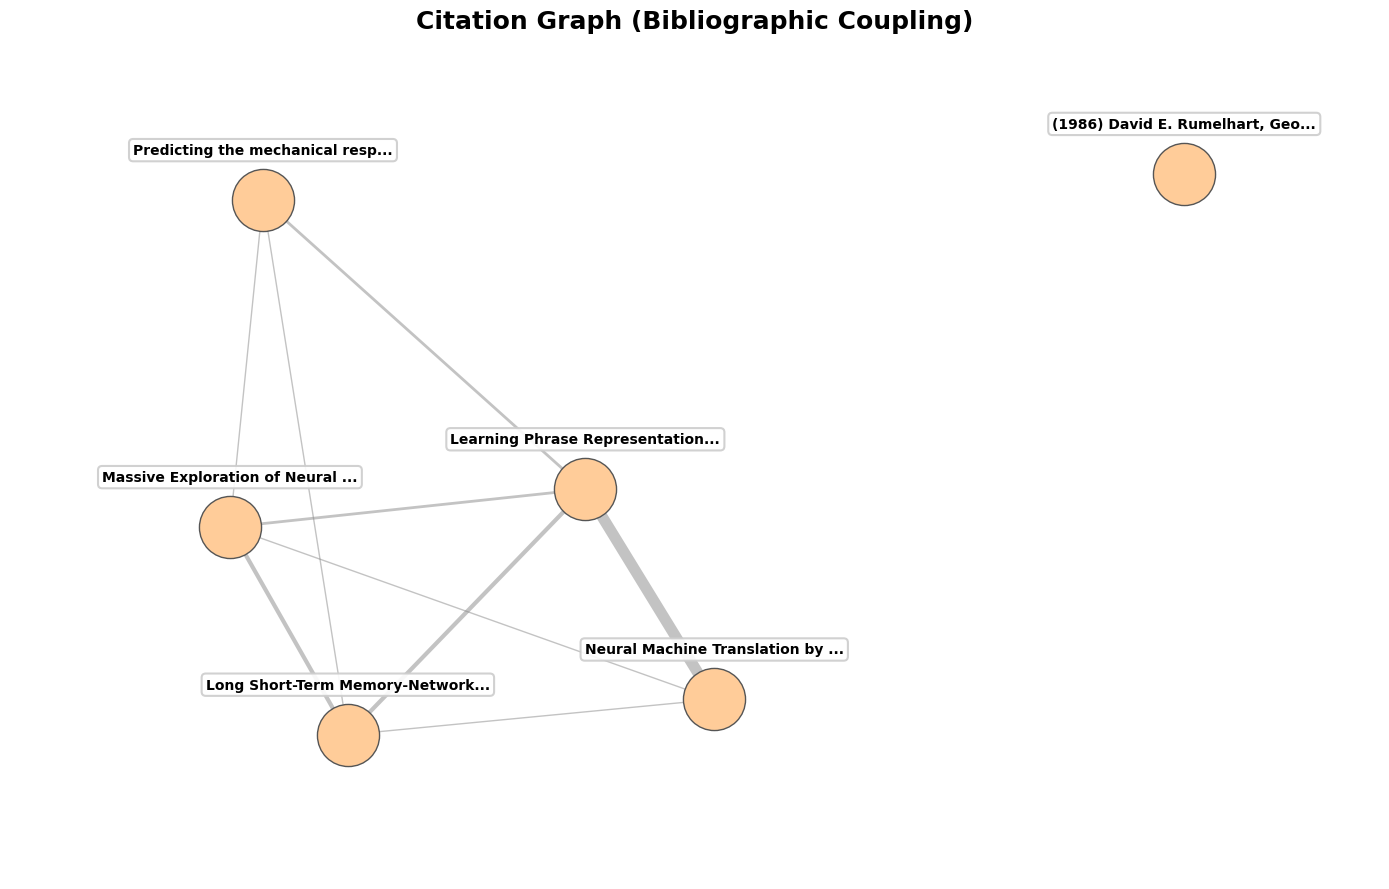

In [8]:
# Visualize the Citation Graph
plt.figure(figsize=(14, 9))

G = cg.graph
pos = nx.spring_layout(G, k=2.0, seed=42)

# Use paper titles for node labels (truncate if too long)
labels = {node: data.get('title', node)[:30] + "..." for node, data in G.nodes(data=True)}

# Edge weights based on number of shared references
edges = G.edges()
weights = [G[u][v].get('weight', 1) for u, v in edges]

nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='#ffcc99', edgecolors='#555555')
nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, alpha=0.5, edge_color='#888888')

# Draw labels slightly above nodes
pos_labels = {node: (coords[0], coords[1] + 0.08) for node, coords in pos.items()}
bbox_props = dict(boxstyle="round,pad=0.3", fc="#ffffff", ec="#cccccc", lw=1.5, alpha=0.9)
nx.draw_networkx_labels(G, pos_labels, labels=labels, font_size=10, font_weight='bold', bbox=bbox_props)

plt.title("Citation Graph (Bibliographic Coupling)", fontsize=18, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.margins(0.2)
plt.show()

In [5]:
# Inspect a specific edge to see their shared references
edges_data = list(G.edges(data=True))
if edges_data:
    u, v, data = edges_data[0]
    title_u = G.nodes[u].get('title', u)
    title_v = G.nodes[v].get('title', v)
    
    print(f"Edge between:\\n- {title_u}\\n- {title_v}\\n")
    print(f"Coupling Weight (Shared References): {data.get('weight', 1)}")
    print(f"Shared Reference IDs (OpenAlex Paper IDs): {data.get('shared_refs', [])}")